In [1]:
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cuda


In [3]:
from utils import SinogramNoise

In [4]:
from dival import get_standard_dataset

dataset = get_standard_dataset(
    "custom",
    data_path="../data/ct_ellipses_dataset",
    sinogram_shape=(256, 183),
    image_shape=(128, 128),
    parts_len={"train": 80, "validation": 10, "test": 10},
    impl="skimage",
)

transform = SinogramNoise(mean=0.0, std=0.0, p=1.0)

test_dataset = dataset.create_torch_dataset(part="test", transform=transform)

In [ ]:
batch_size = 1

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

In [ ]:
from models.Pix2Pix_128_V2 import UnetGeneratorSmall
from models.conv_netx import ConvNetX_128

In [ ]:
generator = UnetGeneratorSmall().to(device)

checkpoint = torch.load("../models/128x128_2701_pix2pix_e200.pth", map_location=device)
generator.load_state_dict(checkpoint)

In [ ]:
def load_generator(checkpoint_path, generator, device="cuda"):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    generator.load_state_dict(checkpoint["generator_state_dict"])

    epoch = checkpoint.get("epoch", None)
    print(
        f"Loaded generator from '{checkpoint_path}' (epoch {epoch})"
    )


# load_generator("checkpoints/checkpoint_10.pt", generator, device)

In [25]:
from torchinfo import summary

# Use the same input shape as the dataset sinograms: (batch, channels, height, width)
model_stats = summary(
    generator,
    input_size=(1, 1, 256, 183),
    col_names=["input_size", "output_size", "num_params", "mult_adds"],
    verbose=0,
)

total_flops = model_stats.total_mult_adds
print(f"Total FLOPs (forward pass): {total_flops:.4e}")
print(f"Total TFLOPs (forward pass): {total_flops / 1e12:.6f}")
print(f"Training TFLOPs (approx 3x forward): {3 * total_flops / 1e12:.6f}")
print()
print(model_stats)

Total FLOPs (forward pass): 3.9712e+10
Total TFLOPs (forward pass): 0.039712
Training TFLOPs (approx 3x forward): 0.119136

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
UnetGeneratorSmall                       [1, 1, 256, 183]          [1, 1, 128, 128]          --                        --
├─ResidualConvBlock: 1-1                 [1, 1, 256, 183]          [1, 64, 256, 183]         --                        --
│    └─Sequential: 2-1                   [1, 1, 256, 183]          [1, 64, 256, 183]         --                        --
│    │    └─Conv2d: 3-1                  [1, 1, 256, 183]          [1, 64, 256, 183]         576                       26,984,448
│    │    └─BatchNorm2d: 3-2             [1, 64, 256, 183]         [1, 64, 256, 183]         128                       128
│    │    └─ReLU: 3-3                    [1, 64, 256, 183]         [1, 64, 256, 183]         --                        --
│    │

In [ ]:
import math
import numpy as np
import lpips
from utils import (
    calculate_mse,
    calculate_psnr,
    calculate_ssim,
    calculate_correlation,
    calculate_lpips,
)

lpips_net = lpips.LPIPS(net="vgg", verbose=False).to(device)

In [42]:
def hu_window(tensor, a=-200, b=200):
    # tensor in (0,1) representing HU [-1024, 3071]
    hu = tensor * (3071 + 1024) - 1024
    hu = torch.clamp(hu, a, b)
    hu = (hu - a) / (b - a)
    return hu

In [ ]:
from tqdm import tqdm
import time

test_windowing = True
hu_windowing_min = -100
hu_windowing_max = 100

generator.eval()

mse_test = []
ssim_test = []
psnr_test = []
correlation_test = []
lpips_test = []

window_mse_test = 0.0
window_ssim_test = 0.0
window_psnr_test = 0.0
window_correlation_test = 0.0
window_lpips_test = 0.0

inference_time_sum = 0.0

with torch.no_grad():
    val_bar = tqdm(test_loader, desc=f"[Test]", leave=False)
    for sino, img in val_bar:
        sino = sino.unsqueeze(1).to(device, non_blocking=True)
        img = img.unsqueeze(1).to(device, non_blocking=True)

        start_time = time.time()
        output = generator(sino)
        end_time = time.time()
        inference_time_sum += (end_time - start_time)

        mse_test.append(calculate_mse(img, output))
        ssim_test.append(calculate_ssim(img, output))
        psnr_test.append(calculate_psnr(img, output, max_val=1.0))
        correlation_test.append(calculate_correlation(img, output))
        lpips_test.append(calculate_lpips(img, output, lpips_net))

        if test_windowing:
            img_window = hu_window(img, a=hu_windowing_min, b=hu_windowing_max)
            window_output = hu_window(output, a=hu_windowing_min, b=hu_windowing_max)

            window_mse_test += calculate_mse(img_window, window_output)
            window_ssim_test += calculate_ssim(img_window, window_output)
            window_psnr_test += calculate_psnr(img_window, window_output, max_val=1.0)
            window_correlation_test += calculate_correlation(img_window, window_output)
            window_lpips_test += calculate_lpips(img_window, window_output, lpips_net)

# Average windowed metrics AFTER the loop
if test_windowing:
    window_mse_test /= len(test_loader)
    window_ssim_test /= len(test_loader)
    window_psnr_test /= len(test_loader)
    window_correlation_test /= len(test_loader)
    window_lpips_test /= len(test_loader)

inference_time_sum_avg = inference_time_sum / (len(test_loader) * batch_size)

print(
    f"Losses: "
    f"MSE: {(sum(mse_test) / len(mse_test)):.6f} | "
    f"SSIM: {(sum(ssim_test) / len(ssim_test)):.4f} | "
    f"PSNR: {(sum(psnr_test) / len(psnr_test)):.4f} | "
    f"Correlation: {(sum(correlation_test) / len(correlation_test)):.4f} | "
    f"LPIPS: {(sum(lpips_test) / len(lpips_test)):.6f}"
)

if test_windowing:
    print(
        f"Windowed Losses: "
        f"MSE: {window_mse_test:.6f} | "
        f"SSIM: {window_ssim_test:.4f} | "
        f"PSNR: {window_psnr_test:.4f} | "
        f"Correlation: {window_correlation_test:.4f} | "
        f"LPIPS: {window_lpips_test:.6f}"
    )

print(
    f"Average inference time per image: {(1000 * inference_time_sum_avg):.2f} milliseconds"
)

In [ ]:
# Plot distribution of test MSE
plt.figure(figsize=(12, 8))
plt.hist(mse_test, bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution of Test MSE")
plt.xlabel("MSE")
plt.ylabel("Frequency")
plt.show()

# Plot distribution of test SSIM
plt.figure(figsize=(12, 8))
plt.hist(ssim_test, bins=20, color="lightgreen", edgecolor="black")
plt.title("Distribution of Test SSIM")
plt.xlabel("SSIM")
plt.ylabel("Frequency")
plt.show()

# Plot distribution of test PSNR
plt.figure(figsize=(12, 8))
plt.hist(psnr_test, bins=20, color="salmon", edgecolor="black")
plt.title("Distribution of Test PSNR")
plt.xlabel("PSNR (dB)")
plt.ylabel("Frequency")
plt.show()

# Plot distribution of test Correlation
plt.figure(figsize=(12, 8))
plt.hist(correlation_test, bins=20, color="plum", edgecolor="black")
plt.title("Distribution of Test Correlation")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Frequency")
plt.show()

# Plot distribution of test LPIPS
plt.figure(figsize=(12, 8))
plt.hist(lpips_test, bins=20, color="lightcoral", edgecolor="black")
plt.title("Distribution of Test LPIPS (lower is better)")
plt.xlabel("LPIPS")
plt.ylabel("Frequency")
plt.show()

### Wyświetlenie obrazów

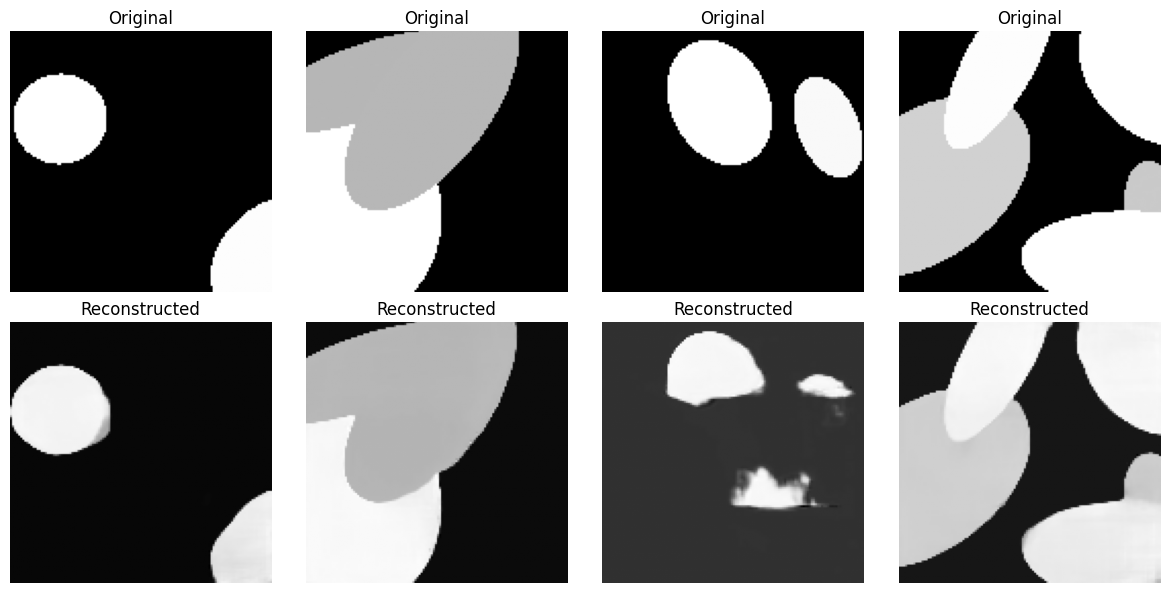

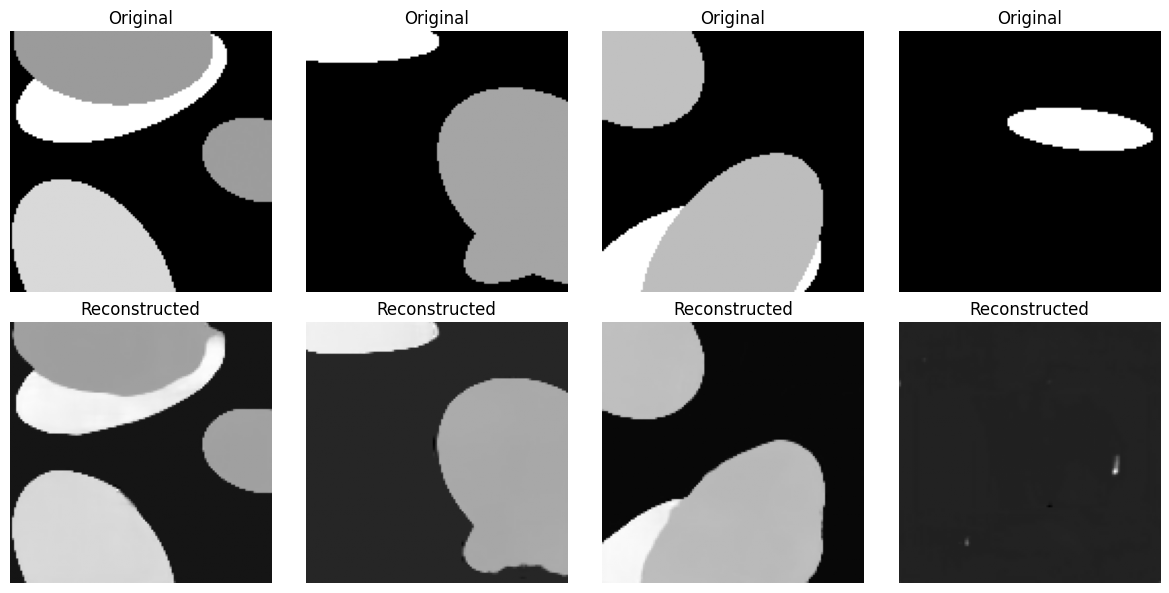

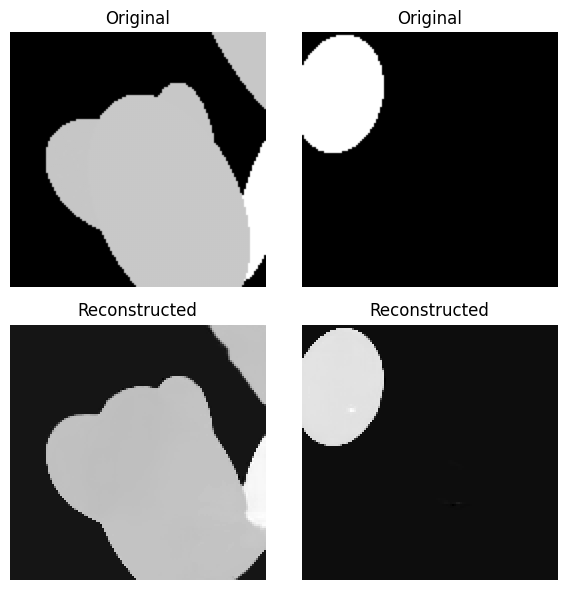

Average inference time per image: 4.87 milliseconds


In [12]:
import matplotlib.pyplot as plt


def show_reconstructed_images(model, dataloader, device, num_images=5):
    model.eval()
    shown = 0
    inference_times = []
    with torch.no_grad():
        for sino, img in dataloader:
            sino = sino.unsqueeze(1).to(device, non_blocking=True)
            img = img.unsqueeze(1).to(device, non_blocking=True)

            start_time = time.time()
            output = model(sino)
            end_time = time.time()
            inference_times.append(end_time - start_time)

            batch_size = img.size(0)
            n = min(batch_size, num_images - shown)

            # Create a figure with 2 rows: original and reconstructed
            fig, axes = plt.subplots(nrows=2, ncols=n, figsize=(3 * n, 6))

            for i in range(n):
                # Original image
                axes[0, i].imshow(img[i].cpu().numpy().squeeze(), cmap="gray")
                axes[0, i].set_title("Original")
                axes[0, i].axis("off")

                # Reconstructed image
                axes[1, i].imshow(output[i].cpu().numpy().squeeze(), cmap="gray")
                axes[1, i].set_title("Reconstructed")
                axes[1, i].axis("off")

            plt.tight_layout()
            plt.show()

            shown += n
            if shown >= num_images:
                break

    average_inference_time = sum(inference_times) / len(inference_times)
    print(
        f"Average inference time per image: {(1000 * average_inference_time / batch_size):.2f} milliseconds"
    )


show_reconstructed_images(generator, test_loader, device, num_images=16)

In [ ]:
# Display 3 representative GT–reconstruction pairs based on MSE distribution
import random

mse_array = np.array(mse_test)
sorted_indices = np.argsort(mse_array)  # ascending (best first)
n_samples = len(sorted_indices)

# Worst 10% (90th–100th percentile of MSE)
worst_10 = sorted_indices[int(0.9 * n_samples):]
# Middle 45–55%
mid_start = int(0.45 * n_samples)
mid_end = int(0.55 * n_samples)
median_range = sorted_indices[mid_start:mid_end]
# Best 10% (0–10th percentile of MSE)
best_10 = sorted_indices[:int(0.1 * n_samples)]

picks = [
    ("Worst 10% MSE", random.choice(worst_10)),
    ("Median 45–55% MSE", random.choice(median_range)),
    ("Best 10% MSE", random.choice(best_10)),
]

fig, axes = plt.subplots(3, 2, figsize=(8, 12))

generator.eval()
with torch.no_grad():
    for row, (label, idx) in enumerate(picks):
        sino, img = test_dataset[idx]
        sino_in = sino.unsqueeze(0).unsqueeze(0).to(device)
        img_in = img.unsqueeze(0).unsqueeze(0).to(device)
        output = generator(sino_in)

        axes[row, 0].imshow(img.numpy().squeeze(), cmap="gray")
        axes[row, 0].set_title(f"Ground Truth (#{idx})")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(output.squeeze().cpu().numpy(), cmap="gray")
        axes[row, 1].set_title(f"Reconstruction — {label}\nMSE: {mse_array[idx]:.6f}")
        axes[row, 1].axis("off")

plt.suptitle("Representative Pairs by MSE Percentile", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Klasyczna rekonstrukcja - porównanie

In [13]:
# Image physical size in meters
MIN_PT = [-0.13, -0.13]
MAX_PT = [0.13, 0.13]

NUM_ANGLES = 256
RECO_IM_SHAPE = (128, 128)

IMPL = "astra_cuda"

In [14]:
import odl
from dival.reconstructors.odl_reconstructors import FBPReconstructor
from dival.util.plot import plot_images

test_pairs = dataset.get_data_pairs(part="test")

reco_space = odl.uniform_discr(
    min_pt=MIN_PT, max_pt=MAX_PT, shape=RECO_IM_SHAPE, dtype=np.float32
)
reco_geometry = odl.tomo.parallel_beam_geometry(reco_space, num_angles=NUM_ANGLES)
reco_ray_trafo = odl.tomo.RayTransform(reco_space, reco_geometry, impl=IMPL)

reconstructor = FBPReconstructor(reco_ray_trafo)

In [ ]:
# Sinogram noise matching training (TARGET_SNR_DB = 45.0).
# Paste the `global_std` printed by train_pix2pix_128.ipynb, or recompute below.
TARGET_SNR_DB = 45.0
NOISE_SEED = 42

@torch.no_grad()
def compute_signal_power_pairs(pairs):
    total_power = 0.0
    total_count = 0
    for obs, _ in pairs:
        arr = np.asarray(obs)
        total_power += float((arr ** 2).sum())
        total_count += arr.size
    return total_power / total_count

signal_power = compute_signal_power_pairs(test_pairs)
noise_std = (signal_power / (10 ** (TARGET_SNR_DB / 10))) ** 0.5
print(f"FBP noise std @ {TARGET_SNR_DB} dB SNR:", noise_std)

rng = np.random.default_rng(NOISE_SEED)

def add_sino_noise(obs):
    arr = np.asarray(obs)
    noisy = arr + rng.normal(0.0, noise_std, size=arr.shape).astype(arr.dtype)
    return reco_ray_trafo.range.element(noisy)

In [ ]:
observation, ground_truth = test_pairs[0]

reconstruction = reconstructor.reconstruct(add_sino_noise(observation))

ground_truth = np.asarray(ground_truth)
reconstruction = np.asarray(reconstruction)

plot_images([ground_truth, reconstruction], fig_size=(15, 6), cbar="auto")

In [ ]:
index_to_display = 7

# Pick the first test sample
sino_torch, img_torch = test_dataset[index_to_display]

# --- Sinogram (numpy, shape H×W) ---
sinogram_np = sino_torch.numpy()          # (256, 183)

# --- Ground-truth image (numpy) ---
gt_np = img_torch.numpy()                 # (128, 128)

# --- Neural-network reconstruction ---
generator.eval()
with torch.no_grad():
    sino_input = sino_torch.unsqueeze(0).unsqueeze(0).to(device)  # (1,1,256,183)
    nn_out = generator(sino_input)                                 # (1,1,128,128)
nn_np = nn_out.squeeze().cpu().numpy()    # (128, 128)

# --- FBP reconstruction (ODL) with noised sinogram ---
observation_fbp, _ = test_pairs[index_to_display]
fbp_np = np.asarray(reconstructor.reconstruct(add_sino_noise(observation_fbp)))   # (128, 128)

# --- Plot ---
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

im0 = axes[0].imshow(sinogram_np, cmap='gray', aspect='auto')
axes[0].set_title('Sinogram', fontsize=13)
axes[0].set_xlabel('Detector bins')
axes[0].set_ylabel('Projection angles')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(gt_np, cmap='gray')
axes[1].set_title('Original Image', fontsize=13)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(nn_np, cmap='gray')
axes[2].set_title('NN Reconstruction', fontsize=13)
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

im3 = axes[3].imshow(fbp_np, cmap='gray')
axes[3].set_title('FBP Reconstruction', fontsize=13)
axes[3].axis('off')
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

plt.suptitle('CT Reconstruction Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Maximum difference value: 0.126329


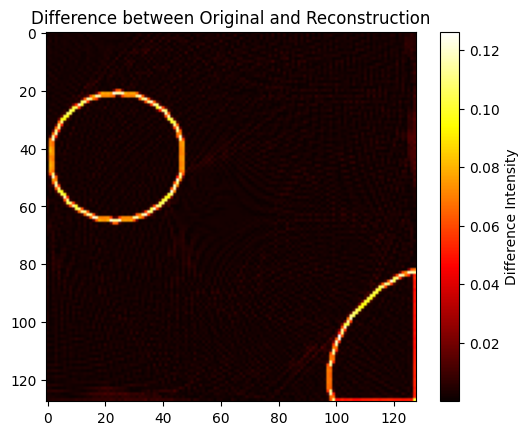

In [17]:
# Compare original and reconstruction pixel by pixel

difference = np.abs(ground_truth - reconstruction)

print("Maximum difference value:", np.max(difference))

plt.imshow(difference, cmap='hot')
plt.title("Difference between Original and Reconstruction")
plt.colorbar(label='Difference Intensity')
plt.show()

In [ ]:
mse_fbp = []
ssim_fbp = []
psnr_fbp = []
correlation_fbp = []
lpips_fbp = []
reconstruction_times = []

for pair in tqdm(test_pairs, desc="[FBP Test]", leave=False):
    observation, ground_truth = pair

    noisy_observation = add_sino_noise(observation)

    start_time = time.time()
    reconstruction = reconstructor.reconstruct(noisy_observation)
    end_time = time.time()
    reconstruction_times.append(end_time - start_time)

    gt_tensor = torch.from_numpy(np.asarray(ground_truth)).float().unsqueeze(0).unsqueeze(0).to(device)
    reco_tensor = torch.from_numpy(np.asarray(reconstruction)).float().unsqueeze(0).unsqueeze(0).to(device)

    mse_fbp.append(calculate_mse(gt_tensor, reco_tensor))
    ssim_fbp.append(calculate_ssim(gt_tensor, reco_tensor))
    psnr_fbp.append(calculate_psnr(gt_tensor, reco_tensor, max_val=1.0))
    correlation_fbp.append(calculate_correlation(gt_tensor, reco_tensor))
    lpips_fbp.append(calculate_lpips(gt_tensor, reco_tensor, lpips_net))

num_pairs = len(test_pairs)
print(
    f"FBP Losses: "
    f"MSE: {(sum(mse_fbp) / num_pairs):.6f} | "
    f"SSIM: {(sum(ssim_fbp) / num_pairs):.4f} | "
    f"PSNR: {(sum(psnr_fbp) / num_pairs):.4f} | "
    f"Correlation: {(sum(correlation_fbp) / num_pairs):.4f} | "
    f"LPIPS: {(sum(lpips_fbp) / num_pairs):.6f}"
)
print(f"Average reconstruction time per image: {(1000 * sum(reconstruction_times) / num_pairs):.2f} milliseconds")

In [ ]:
# Plot distribution of FBP MSE
plt.figure(figsize=(12, 8))
plt.hist(mse_fbp, bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution of FBP MSE")
plt.xlabel("MSE")
plt.ylabel("Frequency")
plt.show()

# Plot distribution of FBP SSIM
plt.figure(figsize=(12, 8))
plt.hist(ssim_fbp, bins=20, color="lightgreen", edgecolor="black")
plt.title("Distribution of FBP SSIM")
plt.xlabel("SSIM")
plt.ylabel("Frequency")
plt.show()

# Plot distribution of FBP PSNR
plt.figure(figsize=(12, 8))
plt.hist(psnr_fbp, bins=20, color="salmon", edgecolor="black")
plt.title("Distribution of FBP PSNR")
plt.xlabel("PSNR (dB)")
plt.ylabel("Frequency")
plt.show()

# Plot distribution of FBP Correlation
plt.figure(figsize=(12, 8))
plt.hist(correlation_fbp, bins=20, color="plum", edgecolor="black")
plt.title("Distribution of FBP Correlation")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Frequency")
plt.show()

# Plot distribution of FBP LPIPS
plt.figure(figsize=(12, 8))
plt.hist(lpips_fbp, bins=20, color="lightcoral", edgecolor="black")
plt.title("Distribution of FBP LPIPS (lower is better)")
plt.xlabel("LPIPS")
plt.ylabel("Frequency")
plt.show()